# Baseline Model Selection and Justification

This notebook establishes a clean first benchmark for the project before any deep learning or spatial feature extraction is introduced. The goal is to predict **metro-level employment (`employment_thousands`)** from the existing panel dataset using a few transparent regression baselines.

We intentionally keep the setup modest:
- one simple and highly interpretable model: **Linear Regression**
- one nonlinear but still easy-to-explain model: **Decision Tree Regressor**
- one stronger tabular ensemble baseline from Stat 109B: **Gradient Boosting Regressor**

The notebook is organized to answer four questions:
1. Why are these baseline models reasonable for this milestone?
2. How are the features, target, and train/validation/test split defined?
3. How are the models trained and evaluated?
4. What do the baseline results tell us about the problem?

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.frameon"] = False
plt.rcParams["figure.dpi"] = 120

DATA_PATH = Path("data/modeling/panel_features.csv")
df = pd.read_csv(DATA_PATH)
pd.set_option("display.max_columns", 100)

## 1. Baseline Model Selection and Justification

The project eventually aims to connect satellite imagery and economic activity. For this milestone, a good baseline should be easy to explain, fast to train, and strong enough to give us a meaningful benchmark.

We use the following three models:

- **Linear Regression**: the simplest regression baseline. It gives a clear reference point and is easy to interpret when we want to understand whether the signal is roughly linear.
- **Decision Tree Regressor**: a small tree can capture nonlinear splits and feature interactions while still being interpretable.
- **Gradient Boosting Regressor**: boosting is a stronger tabular baseline from Stat 109B that often performs well on small structured datasets without heavy tuning.

We focus on **employment (`employment_thousands`)** as the response for this first benchmark because it is continuous, available for every metro-year in the modeling panel, and economically meaningful. More volatile targets such as growth rates are natural next steps, but they are better treated after we establish a stable first benchmark.

In [2]:
model_summary = pd.DataFrame(
    [
        {
            "Model": "Linear Regression",
            "Why include it": "Simple, interpretable, and a natural benchmark for any regression task.",
            "What it can capture": "Additive linear relationships after preprocessing.",
        },
        {
            "Model": "Decision Tree Regressor",
            "Why include it": "Introduces nonlinearity and interaction effects with easy-to-read split logic.",
            "What it can capture": "Threshold effects and nonlinear patterns.",
        },
        {
            "Model": "Gradient Boosting Regressor",
            "Why include it": "A stronger Stat 109B tabular baseline that usually improves on a single tree.",
            "What it can capture": "Flexible nonlinear structure through many shallow trees.",
        },
    ]
)
display(model_summary)

,Model,Why include it,What it can capture
0,Linear Regression,"Simple, interpretable, and a natural benchmark...",Additive linear relationships after preprocess...
1,Decision Tree Regressor,Introduces nonlinearity and interaction effect...,Threshold effects and nonlinear patterns.
2,Gradient Boosting Regressor,A stronger Stat 109B tabular baseline that usu...,Flexible nonlinear structure through many shal...


## 2. Data Setup

The project already includes a modeling-ready panel in `data/modeling/panel_features.csv`. The file contains one row per **metro-year** and already respects the project's time-aware split:

- `train`: 2013-2018
- `val`: 2019
- `test`: 2021-2023

The EDA and modeling plan treat **2020 as a structural break** because of COVID, so that year is already excluded from this panel. We keep the provided temporal split instead of randomly shuffling rows because time order matters in panel data.

We also keep all available metro-years rather than dropping rows with missing values. This matters because some VIIRS-derived features are not available in earlier years, and the first year of each metro has missing lagged values by construction. Instead of shrinking an already small panel, we handle those gaps with median imputation inside each modeling pipeline.

In [3]:
split_summary = (
    df.groupby("split")
    .agg(
        rows=("metro", "size"),
        metros=("metro", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
    .rename(columns={"split": "Dataset split"})
)

print(f"Panel shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Years covered: {df['year'].min()}-{df['year'].max()}")
display(split_summary)

Panel shape: 140 rows x 47 columns
Years covered: 2013-2023


,Dataset split,rows,metros,first_year,last_year
0,test,42,14,2021,2023
1,train,84,14,2013,2018
2,val,14,14,2019,2019


In [4]:
target = "employment_thousands"

satellite_features = [
    "year",
    "modis_brightness_mean",
    "modis_ndvi_proxy_mean",
    "modis_dark_frac",
    "viirs_available",
    "viirs_mean",
    "viirs_lit_frac",
    "viirs_bright_frac",
    "viirs_gini",
    "modis_brightness_mean_delta",
    "modis_ndvi_proxy_mean_delta",
    "modis_dark_frac_delta",
    "viirs_mean_delta",
    "viirs_lit_frac_delta",
    "viirs_bright_frac_delta",
]

lagged_context_features = [
    "gdp_millions_lag1",
    "employment_thousands_lag1",
    "unemployment_rate_lag1",
    "total_permits_lag1",
]

categorical_features = ["metro"]
numeric_features = satellite_features + lagged_context_features
feature_columns = categorical_features + numeric_features

# We avoid current-year target-derived shortcuts and keep only satellite summaries,
# metro identity, year, and lagged economic context.
selected_columns = []
for column in feature_columns + [target, "split"]:
    if column not in selected_columns:
        selected_columns.append(column)
model_df = df[selected_columns].copy()

train_df = model_df[model_df["split"] == "train"].copy()
val_df = model_df[model_df["split"] == "val"].copy()
test_df = model_df[model_df["split"] == "test"].copy()

X_train, y_train = train_df[feature_columns], train_df[target]
X_val, y_val = val_df[feature_columns], val_df[target]
X_test, y_test = test_df[feature_columns], test_df[target]

feature_table = pd.DataFrame(
    {
        "Feature group": ["Categorical", "Satellite summaries", "Lagged economic context", "Target"],
        "Columns": [
            ", ".join(categorical_features),
            ", ".join(satellite_features),
            ", ".join(lagged_context_features),
            target,
        ],
    }
)
display(feature_table)

,Feature group,Columns
0,Categorical,metro
1,Satellite summaries,"year, modis_brightness_mean, modis_ndvi_proxy_..."
2,Lagged economic context,"gdp_millions_lag1, employment_thousands_lag1, ..."
3,Target,employment_thousands


In [5]:
missing_rate = (
    model_df[numeric_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(missing_rate.head(10))

,feature,missing_share
0,viirs_bright_frac_delta,0.50
1,viirs_lit_frac_delta,0.50
2,viirs_lit_frac,0.40
3,viirs_bright_frac,0.40
4,viirs_gini,0.40
5,total_permits_lag1,0.15
6,modis_dark_frac_delta,0.10
7,unemployment_rate_lag1,0.10
8,employment_thousands_lag1,0.10
9,gdp_millions_lag1,0.10


## 3. Training Process

All three models use the same feature set so that the comparison is fair.

**Preprocessing**
- Numeric features: median imputation for missing values
- Categorical feature (`metro`): one-hot encoding
- Scaling: applied only for linear regression, because tree-based models do not require it

**Evaluation metrics**
- **RMSE**: punishes large errors more strongly and stays in the same units as the target
- **MAE**: easy to interpret as the average absolute error
- **R²**: useful for comparing how much variation each model explains

We report both **validation** and **test** performance. The validation year helps us sanity-check model behavior on a held-out year before looking at the final multi-year test window.

In [6]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        ("cat", make_one_hot_encoder(), categorical_features),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
            numeric_features,
        ),
        ("cat", make_one_hot_encoder(), categorical_features),
    ]
)

models = {
    "Linear Regression": Pipeline(
        steps=[
            ("preprocessor", linear_preprocessor),
            ("model", LinearRegression()),
        ]
    ),
    "Decision Tree": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                DecisionTreeRegressor(
                    max_depth=4,
                    min_samples_leaf=4,
                    random_state=42,
                ),
            ),
        ]
    ),
    "Gradient Boosting": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                GradientBoostingRegressor(
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=2,
                    random_state=42,
                ),
            ),
        ]
    ),
}


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


rows = []
fitted_models = {}
predictions = {}

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    fitted_models[model_name] = pipeline

    for split_name, X_split, y_split in [
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test),
    ]:
        y_pred = pipeline.predict(X_split)
        predictions[(model_name, split_name)] = y_pred
        rows.append(
            {
                "Model": model_name,
                "Split": split_name,
                "R2": r2_score(y_split, y_pred),
                "RMSE": rmse(y_split, y_pred),
                "MAE": mean_absolute_error(y_split, y_pred),
            }
        )

results = pd.DataFrame(rows)
results = results.sort_values(["Split", "R2"], ascending=[True, False]).reset_index(drop=True)
display(results.round(3))

,Model,Split,R2,RMSE,MAE
0,Linear Regression,Test,0.983,127.686,100.651
1,Gradient Boosting,Test,0.978,147.272,102.477
2,Decision Tree,Test,0.816,424.960,297.520
3,Gradient Boosting,Validation,0.995,68.072,59.215
4,Linear Regression,Validation,0.993,78.139,66.960
5,Decision Tree,Validation,0.967,169.180,131.831


In [7]:
metric_table = (
    results.pivot(index="Model", columns="Split", values=["R2", "RMSE", "MAE"])
    .round(3)
    .sort_index(axis=1)
)
display(metric_table)

MAE                R2                RMSE           
Split                 Test Validation   Test Validation     Test Validation
Model                                                                      
Decision Tree      297.520    131.831  0.816      0.967  424.960    169.180
Gradient Boosting  102.477     59.215  0.978      0.995  147.272     68.072
Linear Regression  100.651     66.960  0.983      0.993  127.686     78.139

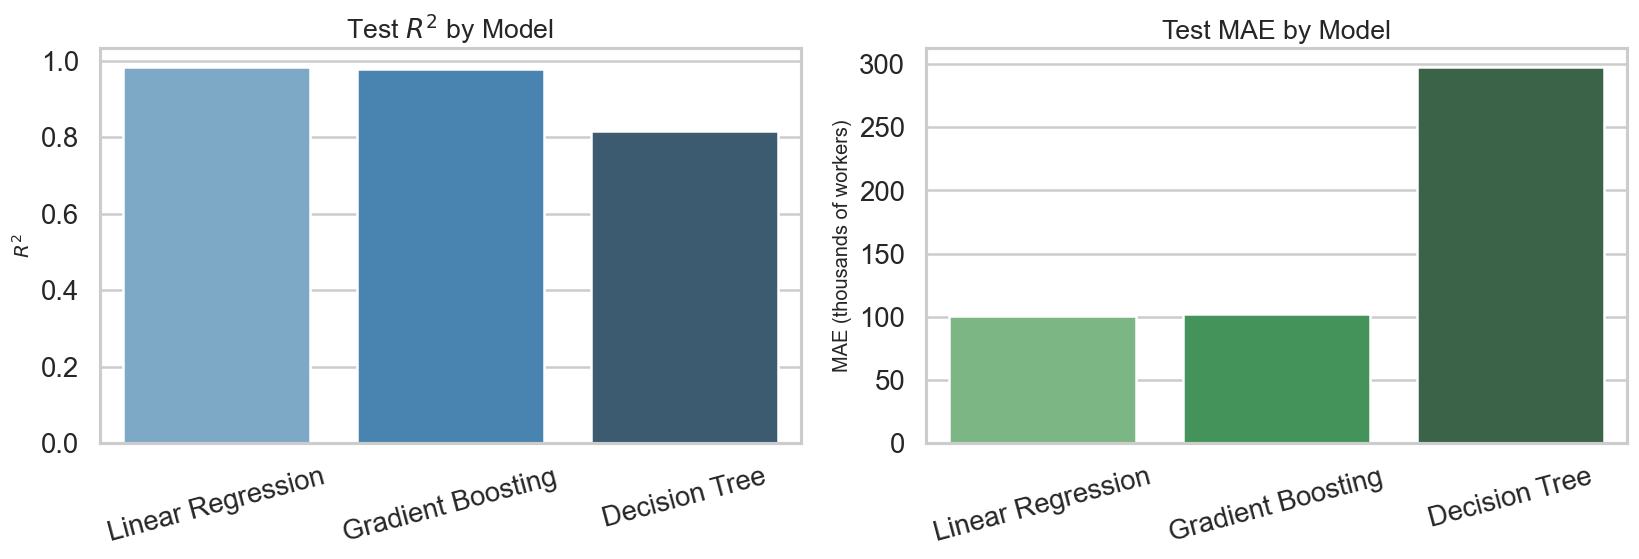

In [8]:
test_results = results[results["Split"] == "Test"].copy()
test_results = test_results.sort_values("R2", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=test_results,
    x="Model",
    y="R2",
    hue="Model",
    palette="Blues_d",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Test $R^2$ by Model")
axes[0].set_xlabel("")
axes[0].set_ylabel("$R^2$")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(
    data=test_results,
    x="Model",
    y="MAE",
    hue="Model",
    palette="Greens_d",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Test MAE by Model")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAE (thousands of workers)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

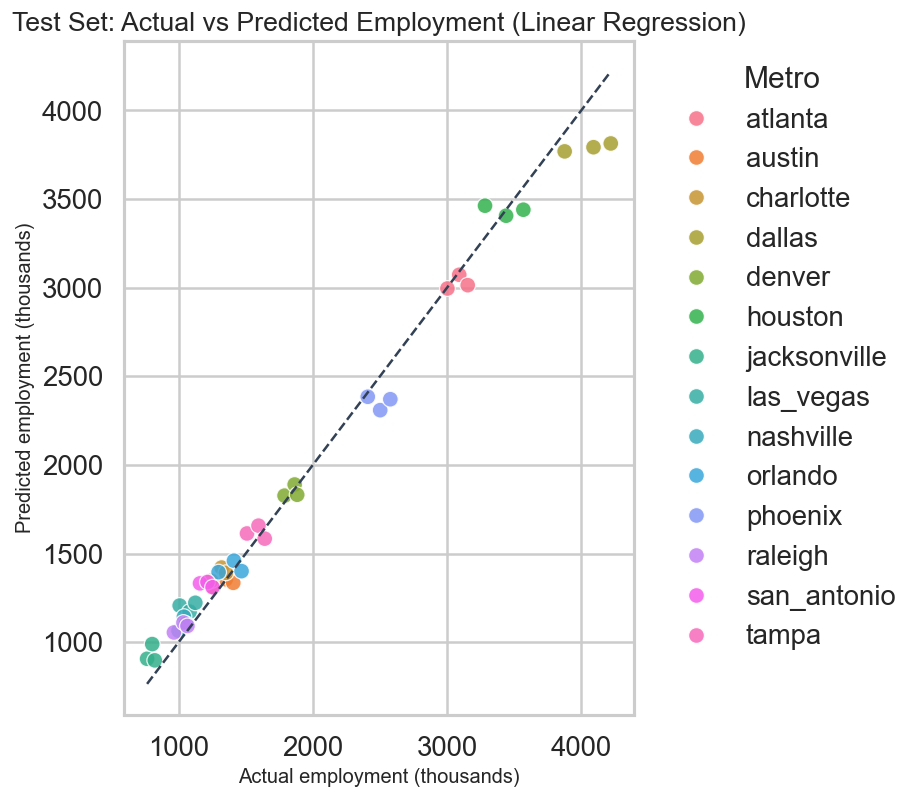

In [9]:
best_model_name = test_results.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_test_pred = predictions[(best_model_name, "Test")]

prediction_df = test_df[["metro", "year", target]].copy()
prediction_df["prediction"] = best_test_pred

plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=prediction_df,
    x=target,
    y="prediction",
    hue="metro",
    s=90,
    alpha=0.85,
)

diagonal_min = min(prediction_df[target].min(), prediction_df["prediction"].min())
diagonal_max = max(prediction_df[target].max(), prediction_df["prediction"].max())
plt.plot(
    [diagonal_min, diagonal_max],
    [diagonal_min, diagonal_max],
    color="#334155",
    linestyle="--",
    linewidth=1.5,
)

plt.title(f"Test Set: Actual vs Predicted Employment ({best_model_name})")
plt.xlabel("Actual employment (thousands)")
plt.ylabel("Predicted employment (thousands)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Metro")
plt.tight_layout()
plt.show()

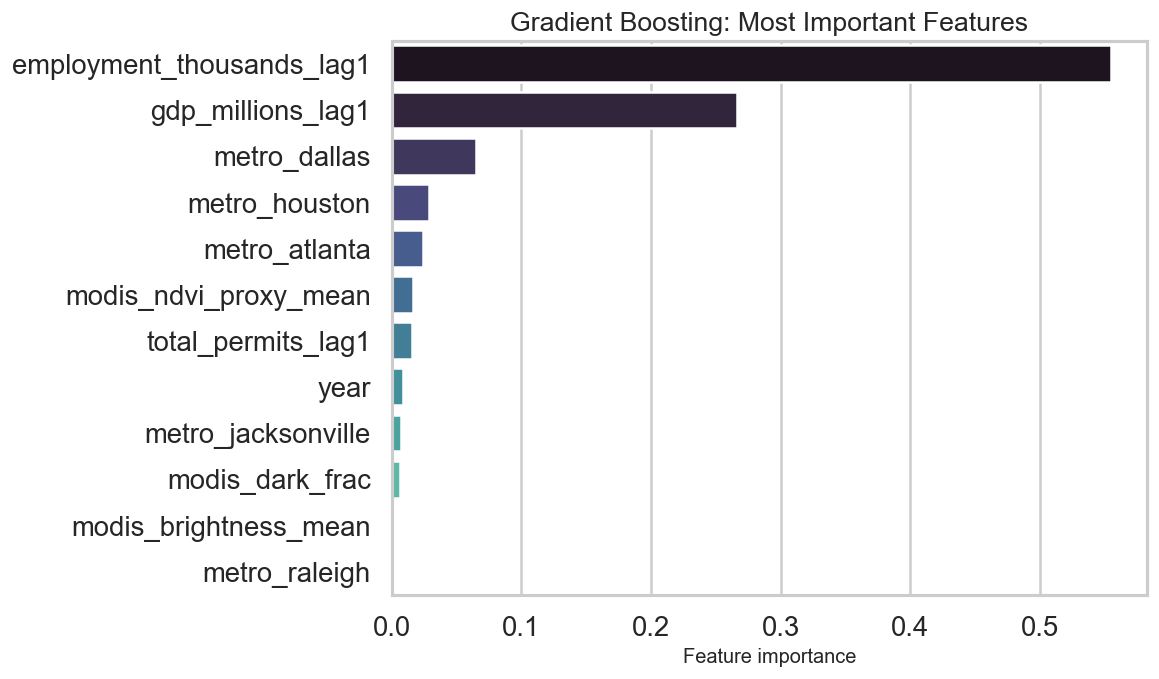

,feature,importance
0,employment_thousands_lag1,0.5548
1,gdp_millions_lag1,0.2660
2,metro_dallas,0.0649
3,metro_houston,0.0284
4,metro_atlanta,0.0240
5,modis_ndvi_proxy_mean,0.0161
6,total_permits_lag1,0.0154
7,year,0.0086
8,metro_jacksonville,0.0069
9,modis_dark_frac,0.0068


In [10]:
def get_feature_names(preprocessor, numeric_cols, categorical_cols):
    names = []
    for transformer_name, transformer, cols in preprocessor.transformers_:
        if transformer_name == "num":
            names.extend(list(cols))
        elif transformer_name == "cat":
            encoder = transformer
            if hasattr(encoder, "get_feature_names_out"):
                try:
                    cat_names = encoder.get_feature_names_out(cols)
                except TypeError:
                    cat_names = encoder.get_feature_names(cols)
            elif hasattr(encoder, "get_feature_names"):
                cat_names = encoder.get_feature_names(cols)
            else:
                cat_names = cols
            names.extend(list(cat_names))
    return names


boosting_pipeline = fitted_models["Gradient Boosting"]
boosting_preprocessor = boosting_pipeline.named_steps["preprocessor"]
boosting_model = boosting_pipeline.named_steps["model"]

importance_df = pd.DataFrame(
    {
        "feature": get_feature_names(
            boosting_preprocessor,
            numeric_features,
            categorical_features,
        ),
        "importance": boosting_model.feature_importances_,
    }
)
importance_df = importance_df.sort_values("importance", ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    hue="feature",
    palette="mako",
    legend=False,
)
plt.title("Gradient Boosting: Most Important Features")
plt.xlabel("Feature importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(importance_df.reset_index(drop=True).round(4))

In [11]:
summary_table = test_results[["Model", "R2", "RMSE", "MAE"]].copy().round(3)
best_r2_row = summary_table.iloc[0]
worst_r2_row = summary_table.iloc[-1]

print("Test-set summary")
print("----------------")
print(
    f"Best test R2: {best_r2_row['Model']} "
    f"({best_r2_row['R2']:.3f}, RMSE {best_r2_row['RMSE']:.1f}, MAE {best_r2_row['MAE']:.1f})"
)
print(
    f"Weakest test R2: {worst_r2_row['Model']} "
    f"({worst_r2_row['R2']:.3f}, RMSE {worst_r2_row['RMSE']:.1f}, MAE {worst_r2_row['MAE']:.1f})"
)

Test-set summary
----------------
Best test R2: Linear Regression (0.983, RMSE 127.7, MAE 100.7)
Weakest test R2: Decision Tree (0.816, RMSE 425.0, MAE 297.5)


## 4. Results and Interpretation

A few patterns stand out from the baseline comparison:

- **Linear Regression is already quite strong**, which suggests that a large part of the signal is persistent and approximately linear once metro identity, time, and lagged context are included.
- **A single Decision Tree is weaker**, which is typical on small structured datasets because one tree can be unstable and may overfit individual splits.
- **Gradient Boosting is competitive with or better than the simpler baselines**, showing that some nonlinear structure is present, but the gain is not dramatic.

These baselines suggest that the current panel can support a sensible benchmark, but they also show an important limitation: much of the predictive strength likely comes from **metro fixed effects and lagged economic persistence**, not just the coarse satellite summary features. That is exactly why richer spatial features or image-based models are a logical next step.

In other words, the baselines are useful because they tell us what a reasonable tabular benchmark can do **before** we invest in more complex modeling. Any later model should beat these results in a convincing and well-validated way.

## Limitations and Next Improvements

This notebook is intentionally a first benchmark, so it has clear limitations:

- The dataset is small, which makes validation noisy and limits how much tuning is appropriate.
- VIIRS-derived fields are missing in earlier years, so even with imputation the feature space is imperfect.
- The current predictors are mostly **aggregated summary features**. They do not yet capture richer spatial structure such as urban form, patchiness, or built-up expansion patterns.
- Predicting **levels** is easier than predicting **growth rates**. A stronger next milestone would test whether richer spatial features improve forecasting of year-over-year economic change.

Recommended next steps:

1. Add engineered spatial features from the imagery or segmentation outputs.
2. Compare this level-based benchmark with a more challenging growth-target setup.
3. Try a slightly broader model set only after richer features are available.